In [1]:
import numpy as np
from zfish._io import import16chFlt
import matplotlib.pyplot as plt
from tqdm import tqdm
from zfish.utils import *
from zfish.swim import *
from zfish.local_path import *

code_id = "5011 - Open Field LS"
loc = join(figpath, code_id)
mkdir(loc)

def process(path):
    res = import16chFlt(path)
    xpos = res['behav_pos_x']
    ypos = res['behav_pos_y']
    idx = np.where(
        (xpos >= 35) &
        (xpos <= 65) &
        (ypos >= 35) &
        (ypos <= 65)
    )[0]
    for k in res.keys():
        res[k] = res[k][idx]
    xpos = res['behav_pos_x']
    ypos = res['behav_pos_y']
    return res, xpos, ypos

        D:\Yao Shuyang\En Lab\Results\5011 - Open Field LS is already existed!


In [3]:
path = r"D:\EnData\Light-sheet\10220\S2\trace.pkl"
with open(path, "rb") as f:
    trace = pickle.load(f)

fish=10220
fish_dir = join(loc, f"{fish}")
os.makedirs(fish_dir, exist_ok=True)
print(trace.keys())

dict_keys(['RawTraces', 'DeconvSignal', 'Fneu', 'iscell', 'roi_coord', 'snr', 'suite2p_version', 'nplanes', 'nchannels', 'tau', 'fs', 'pretrained_model', 'lenX', 'lenY', 'lenZ', 'meanImg', 'nframes', 'FishID', 'session', 'save_dir', 'paradigm', 'position_range', 'n_bins_x', 'n_bins_y', 'dff_method', 'dFF', 'processing_stage', 'last_saved', 'analysis_frame_idx', 'ms_time', 'ms_pos_x', 'ms_pos_y', 'ms_orient', 'ms_map', 'behav_to_ms_idx', 'spike_nodes', 'ms_xy_bins', 'n_neuron', 'rate_map_all', 'occupancy_samples', 'occupancy_seconds', 'min_occupancy_seconds', 'smooth_map_all', 'rate_map_first', 'rate_map_second', 'occupancy_first_samples', 'occupancy_second_samples', 'smooth_map_first', 'smooth_map_second', 'split_half_correlation', 'spatial_information_raw', 'spatial_information_smooth', 'peak_response', 'ptp_response', 'preferred_bin', 'preferred_y_bin', 'preferred_x_bin', 'figure_dir', 'shuffle_ptp_path', 'shuffle_spatial_information_path', 'shuffle_offsets_path', 'n_shuffles', 'min_

# Distribution of Shuffle Test

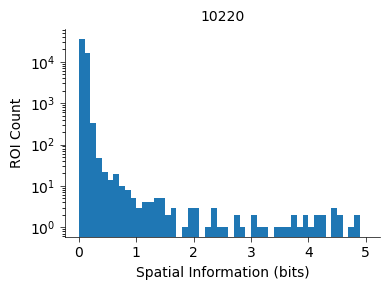

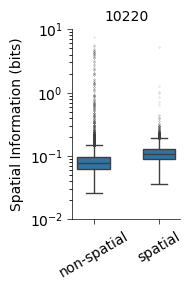

In [12]:
fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(fig.add_subplot(111), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax.set_title(f"{fish}", fontdict={'fontsize': 10})
ax.hist(
    trace['spatial_information_raw'],
    range=(0,5),
    bins=50
)
ax.semilogy(base=10)
ax.set_xlabel("Spatial Information (bits)")
ax.set_ylabel("ROI Count")
plt.tight_layout()
plt.savefig(join(fish_dir, f"SI {fish}.png"))
plt.savefig(join(fish_dir, f"SI {fish}.svg"))
plt.show()

fig = plt.figure(figsize=(2, 3))
ax = Clear_Axes(fig.add_subplot(111), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
is_passed = np.where(trace['spatial_information_shuffle_p'] < 0.05, 1, 0)
sns.boxplot(
    x=is_passed,
    y=trace['spatial_information_raw'],
    width=0.5,
    fliersize=0.1
)
ax.set_title(f"{fish}", fontdict={'fontsize': 10})
ax.semilogy(base=10)
ax.set_ylim(0.01, 10)
ax.set_xticks([0, 1], ['non-spatial', 'spatial'], rotation=30)
ax.set_ylabel("Spatial Information (bits)")
plt.tight_layout()
plt.savefig(join(fish_dir, f"SI Passed Shuffle {fish}.png"))
plt.savefig(join(fish_dir, f"SI Passed Shuffle {fish}.svg"))
plt.show()


13542 (52495,)


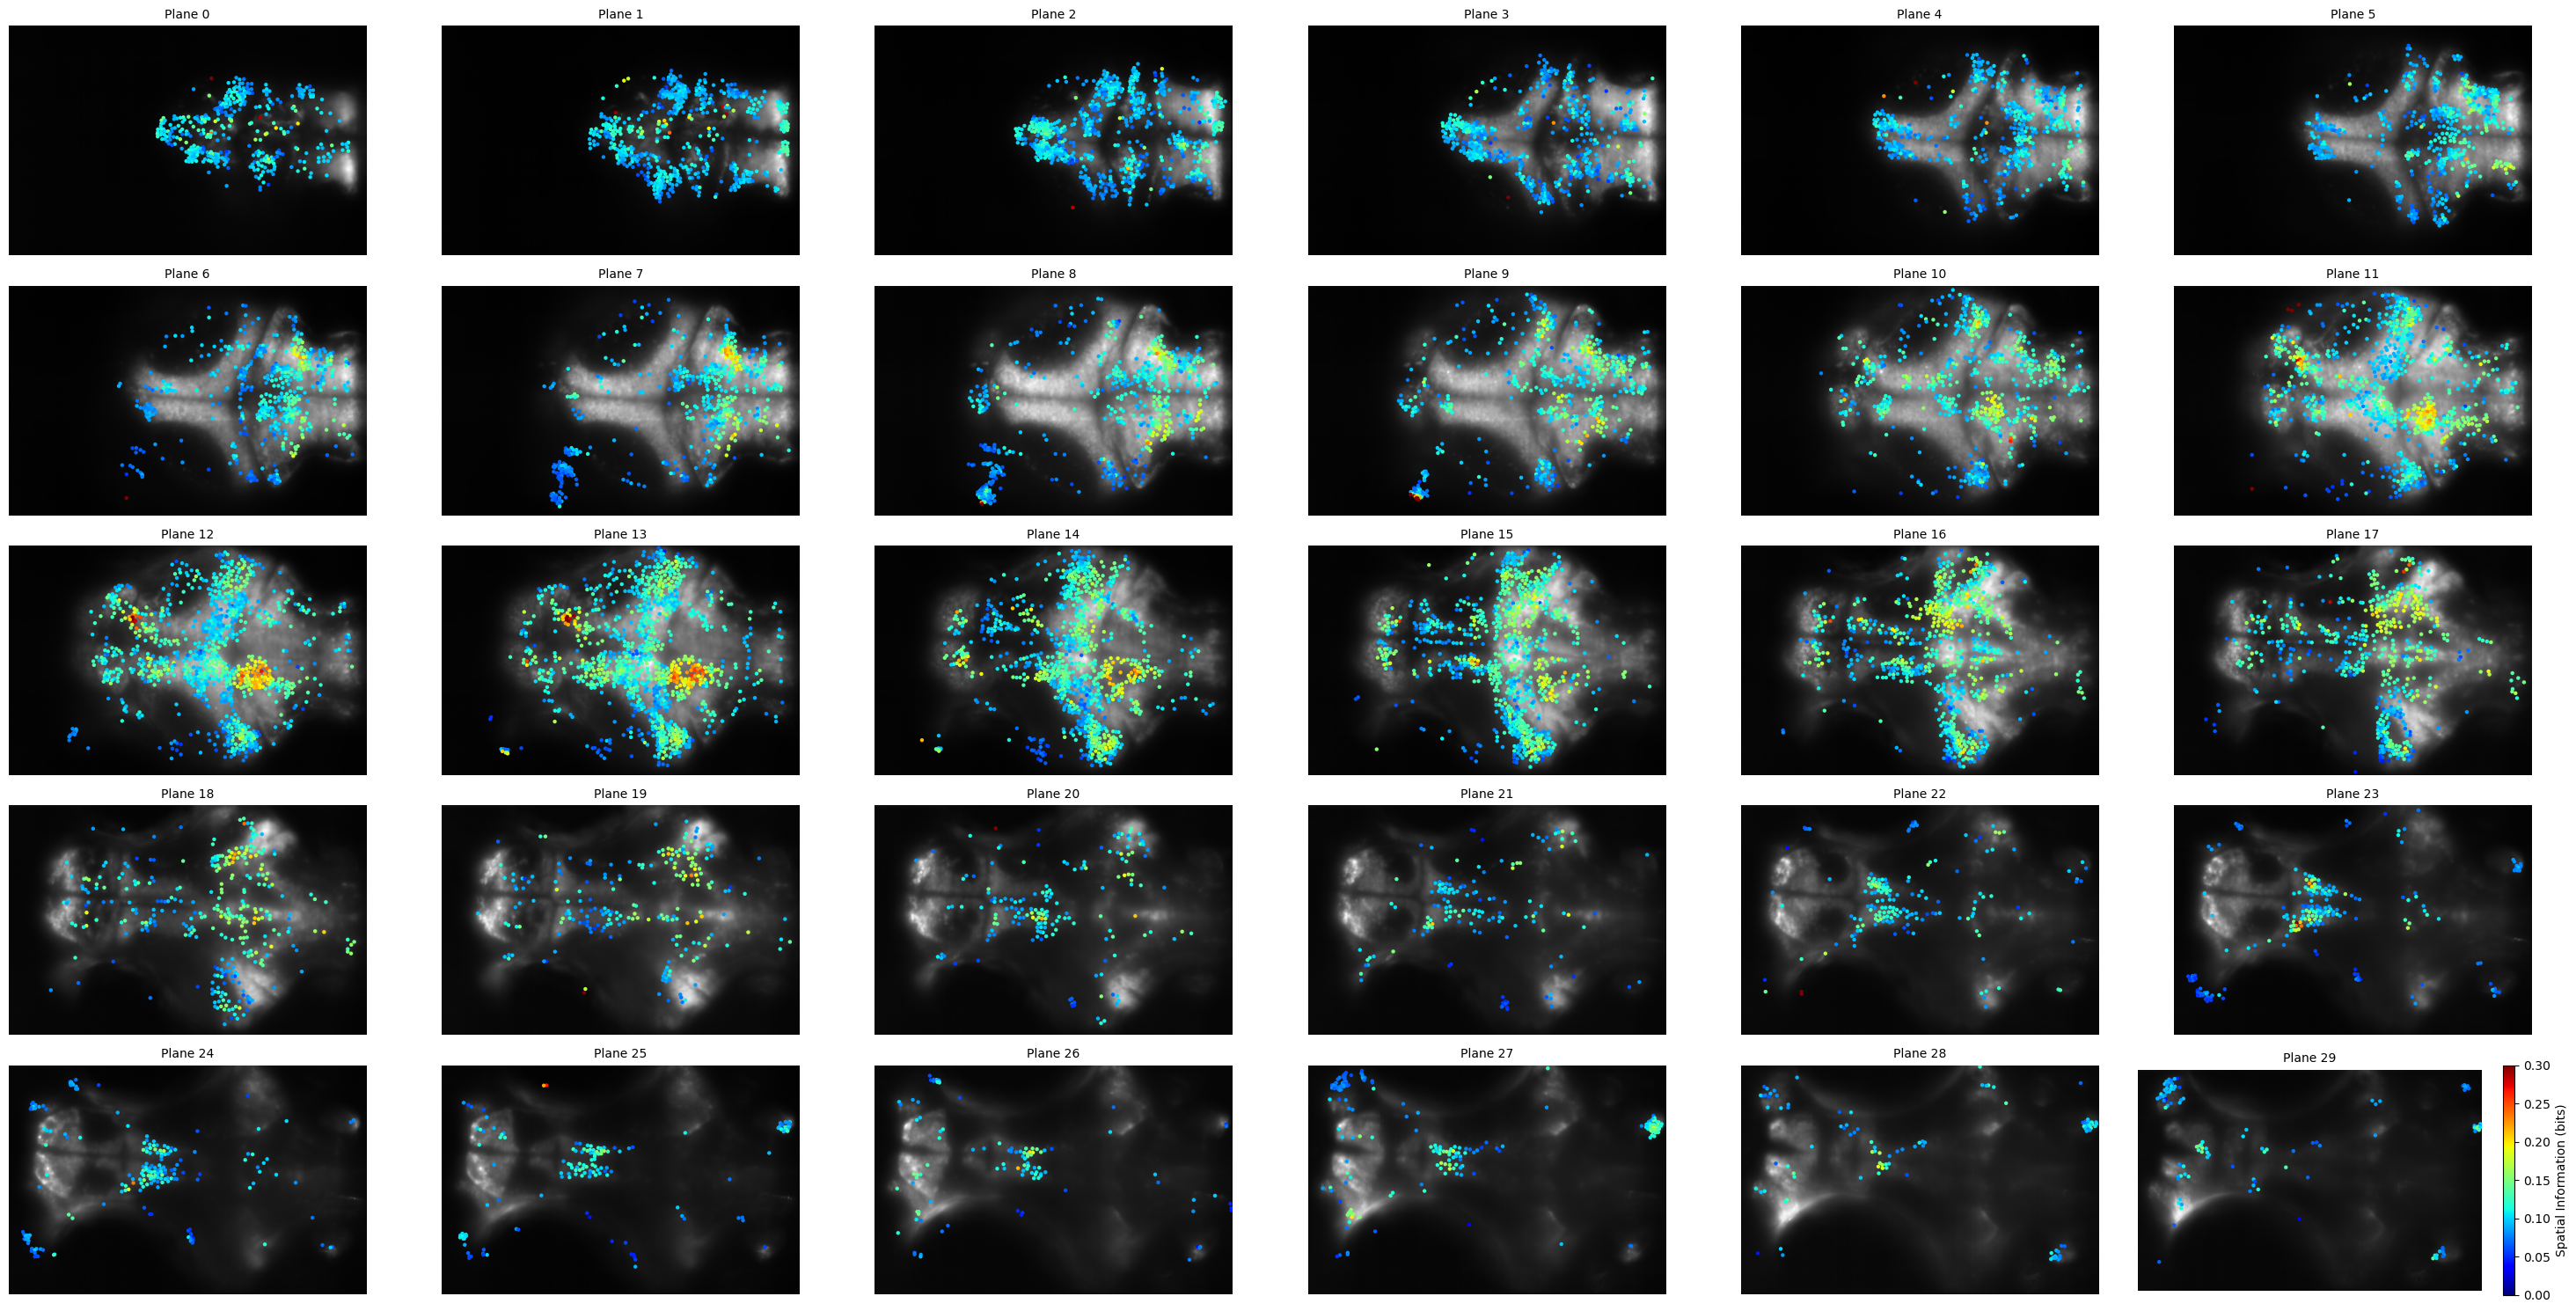

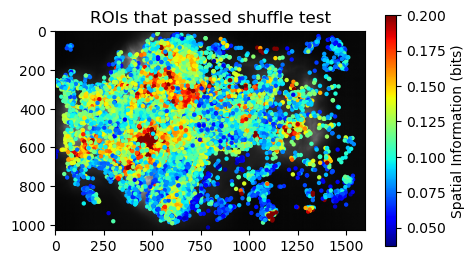

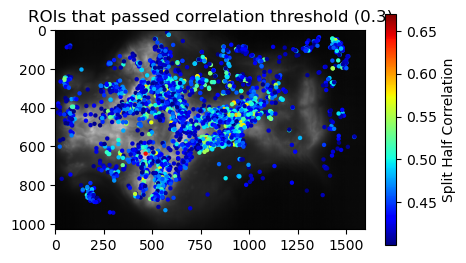

In [22]:
idx = np.where((trace['spatial_information_shuffle_p'] < 0.05))[0]
print(idx.shape[0], trace['spatial_information_raw'].shape)
spatial_cell = idx
meanImg, ROI = get_meanImg(trace)

fig, axes = plt.subplots(figsize=(5*6, 3*5), ncols=6, nrows=5)
for i in range(6):
    for j in range(5):
        ax = Clear_Axes(axes[j, i])
        nplane = j * 6 + i
        if nplane < meanImg.shape[2]:
            cell_in_plane = np.where(ROI[idx, 2] == nplane)[0]
            im = ax.scatter(
                ROI[idx[cell_in_plane], 0], 
                ROI[idx[cell_in_plane], 1], 
                s=10, 
                edgecolor=None, 
                linewidth=0, 
                c=trace['spatial_information_raw'][idx[cell_in_plane]], 
                vmax=0.3,
                vmin=0,
                cmap='jet'
            )
            ax.imshow(meanImg[:, :, nplane], cmap='gray')
            if nplane == 29:
                cbar = fig.colorbar(im, ax=ax)
                cbar.set_label('Spatial Information (bits)')
            ax.set_title(f"Plane {nplane}", fontdict={'fontsize': 10})
            ax.invert_xaxis()
plt.tight_layout()
plt.savefig(join(fish_dir, f"Plane-wise Spatial Cell Distribution.png"), dpi=300)
plt.savefig(join(fish_dir, f"Plane-wise Spatial Cell Distribution.svg"))
plt.show()

fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(111)
im = ax.scatter(ROI[idx, 0], ROI[idx, 1], s=10, edgecolor=None, linewidth=0, c=trace['spatial_information_raw'][idx], vmax=0.2, cmap='jet')
ax.imshow(np.median(meanImg, axis=2), cmap='gray')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Spatial Information (bits)')
ax.set_title("ROIs that passed shuffle test")
plt.savefig(join(loc, f"ROIs_passed_shuffle_test_{fish}.png"))
plt.savefig(join(loc, f"ROIs_passed_shuffle_test_{fish}.svg"))
plt.show()

corr_idx = np.where((trace['split_half_correlation'] > 0.4))[0]
fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(111)
im = ax.scatter(ROI[corr_idx, 0], ROI[corr_idx, 1], s=10, edgecolor=None, linewidth=0, c=trace['split_half_correlation'][corr_idx], cmap='jet')
ax.imshow(np.median(meanImg, axis=2), cmap='gray')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Split Half Correlation')
ax.set_title("ROIs that passed correlation threshold (0.3)")
plt.savefig(join(loc, f"ROIs_passed_correlation_{fish}.png"))
plt.savefig(join(loc, f"ROIs_passed_correlation_{fish}.svg"))
plt.show()


# Visualize DA Neural Responses

(438,)


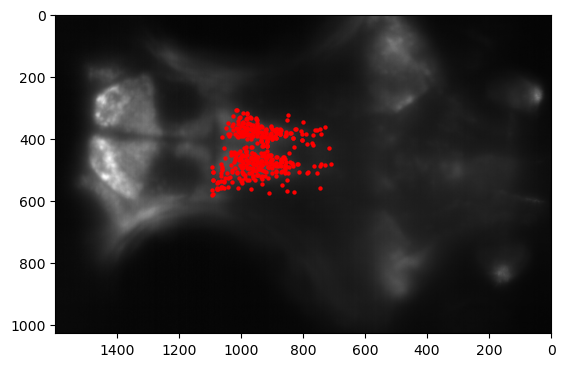

In [35]:
planes = np.arange(22, 28)
DA_idx = np.where(
    (np.isin(ROI[:, 2], planes))&
    (trace['spatial_information_shuffle_p'] < 0.05) &
    (ROI[:, 0] <= 1100) &
    (ROI[:, 1] <= 600) &
    (ROI[:, 0] >= 700) & 
    (ROI[:, 1] >= 300)
)[0]
print(DA_idx.shape)
imm = np.median(meanImg[:, :, planes], axis=2)

plt.imshow(imm, cmap='gray')
plt.scatter(ROI[DA_idx, 0], ROI[DA_idx, 1], s=10, edgecolor=None, linewidth=0, c='r')
plt.gca().invert_xaxis()

        D:\Yao Shuyang\En Lab\Results\5011 - Open Field LS\10220\DA Nneuron is already existed!


100%|██████████| 438/438 [01:47<00:00,  4.08it/s]


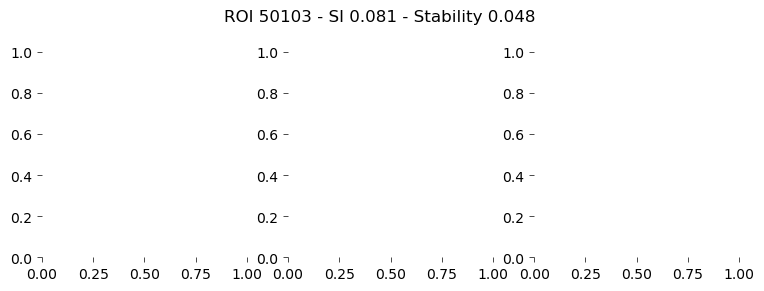

In [33]:
save_loc = join(loc, "10220", "DA Nneuron")
mkdir(save_loc)
N_BIN = 15
def visualize(trace, idx=None):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9, 3))
    ax0 = Clear_Axes(axes[0])
    ax1 = Clear_Axes(axes[1])
    ax2 = Clear_Axes(axes[2])
    
    if idx is None:
        idx = range(trace['n_neuron'])
    for i in tqdm(idx):
        vmax = np.nanmax([
            np.nanmax(trace['rate_map_all'][i]),
            np.nanmax(trace['rate_map_first'][i]),
            np.nanmax(trace['rate_map_second'][i])
        ])
        vmax = 1 if np.isnan(vmax) else vmax
        vmin = np.nanmin([
            0, 
            np.nanmin(trace['rate_map_all'][i]),
            np.nanmin(trace['rate_map_first'][i]),
            np.nanmin(trace['rate_map_second'][i])
        ])
        vmin = 0 if np.isnan(vmin) else vmin
        
        ax0.imshow(np.reshape(trace['rate_map_all'][i], (N_BIN, N_BIN)), vmax=vmax, vmin=vmin)
        ax1.imshow(np.reshape(trace['rate_map_first'][i], (N_BIN, N_BIN)), vmax=vmax, vmin=vmin)
        ax2.imshow(np.reshape(trace['rate_map_second'][i], (N_BIN, N_BIN)), vmax=vmax, vmin=vmin)
        ax0.set_title("All")
        ax1.set_title("First")
        ax2.set_title("Second")
        plt.suptitle(f"ROI {i} - SI {trace['spatial_information_smooth'][i]:.3f} - Stability {trace['split_half_correlation'][i]:.3f}")
        plt.savefig(join(save_loc, f"ROI {i}.png"))
        ax0.clear()
        ax1.clear()
        ax2.clear()
    plt.show()
    
visualize(trace, DA_idx)

# Peak Rate Distribution

(35.0, 65.0, 35.0, 65.0)

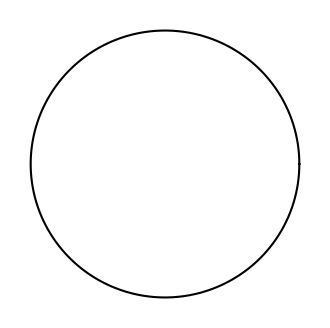

In [ ]:
fig = plt.figure(figsize=(4, 4))
ax = Clear_Axes(fig.add_subplot(1, 1, 1))
theta = np.linspace(0, 2 * np.pi, 1000)
x = np.cos(theta)*13+50
y = np.sin(theta)*13+50
ax.plot(x, y, color='k')
ax.axis([35, 65, 35, 65])
ax.scatter()